In [1]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [2]:
df = sns.load_dataset("iris")

In [3]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: >

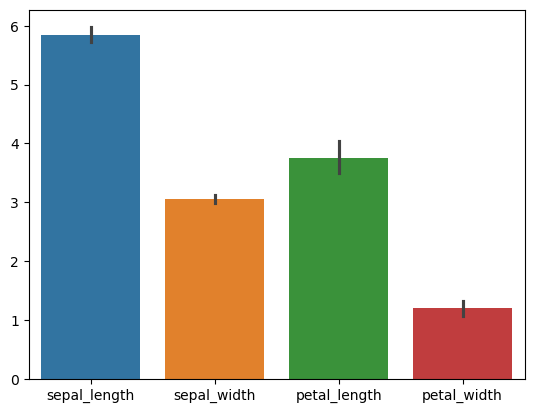

In [5]:
sns.barplot(data=df)

In [6]:
x = df.drop('species', axis=1)
y = df['species']

In [7]:
le = LabelEncoder()
y_encode = le.fit_transform(y)

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y_encode)

In [10]:
base_learner = [
    ("svm", SVC(kernel='rbf', random_state=42)),
    ("dt", DecisionTreeClassifier(random_state=42)),
    ("lr", LogisticRegression(max_iter=1000))
]

In [20]:
meta_learner = KNeighborsClassifier(n_neighbors=9)

In [21]:
from sklearn.ensemble import StackingClassifier

In [22]:
stacking_class = StackingClassifier(
    estimators=base_learner,
    final_estimator=meta_learner,
    cv=5
)

In [23]:
stacking_class.fit(x_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('svm', SVC(random_state=42)),
                               ('dt', DecisionTreeClassifier(random_state=42)),
                               ('lr', LogisticRegression(max_iter=1000))],
                   final_estimator=KNeighborsClassifier(n_neighbors=9))

In [24]:
y_pred_stacking = stacking_class.predict(x_test)

In [25]:
accuracy_score(y_test, y_pred_stacking)

0.9666666666666667

In [26]:
# Use random forest classifier

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
model_rf = RandomForestClassifier(n_estimators=150, random_state=42)
model_rf.fit(x_train, y_train)

RandomForestClassifier(n_estimators=150, random_state=42)

In [32]:
y_pred_rf = model_rf.predict(x_test)

In [33]:
accuracy_score(y_test, y_pred_rf)

0.9